# Tutoring Center Data Cleaning, Analysis, and Visualization Lab

## Scenario
You are the junior data analyst for **BrightFuture Tutoring Center**.

The center exported a messy training file. Your job is to:
1. load it safely,
2. clean it,
3. transform it,
4. inspect missing values and duplicates,
5. create useful features,
6. analyze performance patterns,
7. visualize the results with **pandas**, **Matplotlib**, and **Seaborn**.

## Files included
- `tutoring_center_raw.txt` → messy raw export
- `tutoring_center_big.csv` → larger file for chunking practice
- `tutoring_center_clean_reference.csv` → clean reference copy of the same synthetic data

## Main goal
Answer this business question:

> **Which factors seem most related to higher student scores, and how do results differ by study type and campus region?**

This notebook is designed to practice many core ideas:
- careful file loading
- `head()`, `info()`, `isna()`, `dropna()`, `fillna()`
- `replace()` vs `map()`
- renaming columns
- removing duplicates
- type conversion
- categorical data
- `cut()` and `qcut()`
- outlier flags with z-scores
- sampling and shuffling
- `loc` / `iloc`
- sorting, ranking, summaries, `groupby()`
- pandas plots
- Matplotlib object model and subplots
- Seaborn relational, categorical, distribution, heatmap, and regression plots

## Part 0. Setup

Import the libraries you need for cleaning and plotting.

Use:
- `pandas`
- `numpy`
- `matplotlib.pyplot`
- `seaborn`

Also set:
- `pd.set_option("display.max_columns", None)`
- a Seaborn theme

In [1]:
# TODO:
# 1) import pandas as pd
# 2) import numpy as np
# 3) import matplotlib.pyplot as plt
# 4) import seaborn as sns

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## Part 1. Load the raw file correctly

### Your task
Read the file into a DataFrame called `df`.

### Conditions
- the file is pipe-separated,
- the first line should be skipped,
- `NA`, `?`, `Unknown`, and empty strings should be treated as missing values.

Store the result in `df`, then display the first few rows.

In [5]:
tutoring = pd.read_csv('tutoring_center_big.csv')
tutoring.head(5)


,student_id,exam_date,gender,study_type,campus_region,program_level,hours_studied,attendance_pct,practice_tests,sleep_hours,score,passed,tutor_rating,notes,batch
0,ST1001,2025-02-02,Female,1-on-1,East,1,5.4,75.6,5,6.2,71.0,Pass,2,excellent focus,1
1,ST1002,2025-10-10,Female,Solo,West,3,12.7,100.0,5,6.2,96.0,Pass,4,needs reminder,1
2,ST1003,2025-08-27,Male,Solo,Central,2,10.9,80.8,4,5.7,80.2,Pass,2,needs reminder,1
3,ST1004,2025-06-10,Male,Solo,West,2,7.7,95.4,1,7.7,91.6,Pass,4,excellent focus,1
4,ST1005,2025-06-08,Male,Online,Central,1,23.5,71.2,3,6.9,96.9,Pass,4,prefers group work,1


## Part 2. Inspect the DataFrame

Use code to answer:
- What is the shape of the dataset?
- What are the column names?
- Which columns have missing values?
- What are the current data types?

Run:
- `df.shape`
- `df.columns`
- `df.info()`
- `df.isna().sum()`

In [6]:
# TODO:
# Run the four checks listed above.
print(tutoring.shape)
print('----------------------')
print(tutoring.columns)
print('----------------------')
print(tutoring.info())
print('----------------------')
print(tutoring.isna().sum())

(28800, 15)
----------------------
Index(['student_id', 'exam_date', 'gender', 'study_type', 'campus_region',
       'program_level', 'hours_studied', 'attendance_pct', 'practice_tests',
       'sleep_hours', 'score', 'passed', 'tutor_rating', 'notes', 'batch'],
      dtype='object')
----------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28800 entries, 0 to 28799
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   student_id      28800 non-null  object 
 1   exam_date       28800 non-null  object 
 2   gender          28800 non-null  object 
 3   study_type      28800 non-null  object 
 4   campus_region   28800 non-null  object 
 5   program_level   28800 non-null  int64  
 6   hours_studied   28800 non-null  float64
 7   attendance_pct  28800 non-null  float64
 8   practice_tests  28800 non-null  int64  
 9   sleep_hours     28800 non-null  float64
 10  score           28800 non-null  float6

## Part 5. Detect and remove duplicate rows

Check how many duplicate rows exist.

Then drop duplicates and **reassign** the result back to `df`.

That reassignment step matters. Pandas does not magically rewrite the DataFrame just because humans wish really hard.

In [7]:
# TODO:
# 1) Count duplicates with df.duplicated().sum()
# 2) Remove them
# 3) Reassign the cleaned result back to df
# 4) Check the shape again

print(tutoring.duplicated().sum())

0


## Part 6. Standardize messy text values

Several columns contain inconsistent labels:
- `Gender` appears as `Male`, `male`, `M`, `Female`, `female`, `F`
- `Study Type` appears in mixed styles
- `Campus Region` uses odd capitalization and spaces
- `Passed` appears as `Pass`, `PASS`, `Fail`, `fail`

### Your job
1. strip spaces from text columns,
2. fix category labels using `replace()`,
3. use `map()` to turn `program_level` codes into meaningful labels.

In [8]:
# TODO:
# First, strip spaces from the main text columns.
# Suggested text columns:
# ['gender', 'study_type', 'campus_region', 'passed', 'notes']

cols = ['gender', 'study_type', 'campus_region', 'passed', 'notes']

for col in cols:
    tutoring[col] = tutoring[col].str.strip()

# First check if standardization is needed or not:
for col in cols:
    print(tutoring[col].value_counts())
# No need for standardization

gender
Female    15600
Male      13200
Name: count, dtype: int64
study_type
Solo      10080
Group      7320
Online     6840
1-on-1     4560
Name: count, dtype: int64
campus_region
Central    6600
West       5880
North      5760
East       5520
South      5040
Name: count, dtype: int64
passed
Pass    28440
Fail      360
Name: count, dtype: int64
notes
excellent focus          3360
prefers group work       3360
late submission once     3360
prefers solo revision    3120
quiet in class           3120
needs reminder           2880
review algebra           2520
good improvement         2520
steady progress          1920
Name: count, dtype: int64


## Part 7. Convert data types properly

- `exam_date` to datetime

Then inspect the dtypes again.

In [9]:
# TODO:
# Convert exam_date with pd.to_datetime(..., errors="coerce")
# Then inspect df.dtypes or df.info()
tutoring['exam_date'] = pd.to_datetime(tutoring['exam_date'], errors='coerce')
print(tutoring.dtypes)

student_id                object
exam_date         datetime64[ns]
gender                    object
study_type                object
campus_region             object
program_level              int64
hours_studied            float64
attendance_pct           float64
practice_tests             int64
sleep_hours              float64
score                    float64
passed                    object
tutor_rating               int64
notes                     object
batch                      int64
dtype: object


## Part 8. Handle missing data

Not every missing value should be treated the same way.

### Suggested decision rule
- missing `student_id` → drop the row
- missing `score` → drop the row because it is the main outcome
- missing numeric support columns → fill with median
- missing categorical columns → fill with `"Unknown"`
- missing notes → fill with `"No note"`

Then check missing values again.

In [13]:
columns = tutoring.columns
cols = list(columns)

for col in cols:
    print(col)
    print(tutoring[col].isna().sum())

student_id
0
exam_date
0
gender
0
study_type
0
campus_region
0
program_level
0
hours_studied
0
attendance_pct
0
practice_tests
0
sleep_hours
0
score
0
passed
0
tutor_rating
0
notes
2640
batch
0


In [16]:
tutoring['notes'] = tutoring['notes'].replace(np.nan, 'No note')
print(tutoring['notes'].isna().sum())
print((tutoring['notes'] == 'No note').sum())

0
2640


## Part 9. Convert useful columns to categorical data

Convert these to category dtype:
- `gender`
- `study_type`
- `campus_region`
- `passed`

Then make `program_level_label` an **ordered category** in this order:
1. Foundation
2. Intermediate
3. Advanced

Finally, inspect the categories or the DataFrame info.

In [18]:
# TODO:
# Convert the listed columns to category.
cols = ['gender', 'study_type', 'campus_region', 'passed']
for col in cols:
    tutoring[col] = tutoring[col].astype('category')

tutoring['program_level_label'] = tutoring['program_level'].replace({1: 'Foundation', 2: 'Intermediate', 3: 'Advanced'})
tutoring['program_level_label'] = pd.Categorical(tutoring['program_level_label'], categories=['Foundation', 'Intermediate', 'Advanced'], ordered=True)

for col in cols:
    print(tutoring[col].dtype)

print(tutoring['program_level_label'].value_counts())
print(tutoring['program_level_label'].dtype)
# Then use pd.Categorical(...) to create an ordered category for program_level_label.


category
category
category
category
program_level_label
Intermediate    11640
Foundation       8760
Advanced         8400
Name: count, dtype: int64
category


## Part 10. Create new features with transformation

Create:
- `score_band` using `pd.cut()`

### Suggested score bands
- 0 to 50 → Needs Help
- 50 to 65 → Borderline
- 65 to 80 → Good
- 80 to 100 → Excellent
- 100 to 150 → Extreme

In [21]:
bins = [0, 50, 65, 80, 100, 150]
labels = ['Needs Help', 'Borderline', 'Good', 'Excellent', 'Extreme']

tutoring['score_band'] = pd.cut(tutoring['score'], bins=bins, labels=labels)
print(tutoring['score_band'].value_counts())

score_band
Excellent     18935
Good           7323
Extreme        1626
Borderline      916
Needs Help        0
Name: count, dtype: int64


## Part 11. Flag outliers with z-score intuition

Create z-scores for:
- `hours_studied`
- `score`

Then flag outliers where `abs(z) > 3`.

Create:
- `hours_z`
- `score_z`
- `is_hours_outlier`
- `is_score_outlier`

Display the suspicious rows.

In [28]:
hours_studied_z = (tutoring['hours_studied'] - tutoring['hours_studied'].mean()) / tutoring['hours_studied'].std()

score_z = (tutoring['score'] - tutoring['score'].mean()) / tutoring['score'].std()

is_hours_outlier = hours_studied_z[abs(hours_studied_z) > 3]
is_score_outlier = score_z[abs(score_z) > 3]

print(is_hours_outlier.count())
print(is_score_outlier.count())

258
139


In [ ]:
# Remove outliers from dataset
hours_mask = abs(hours_studied_z) <= 3
score_mask = abs(score_z) <=3

tutoring = tutoring[hours_mask & score_mask]

print(tutoring['hours_studied'].count())
print(tutoring['score'].count())

28403
28403


/var/folders/m_/5hjxnlm94j53h6kj050rk1300000gn/T/ipykernel_71392/3481853163.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  tutoring = tutoring[hours_mask & score_mask]


## Part 14. Sort, rank, summarize, and group

### Tasks
1. Create a dense rank for score called `score_rank`.
2. Show numeric summary statistics.
3. Show value counts for `study_type`.
4. Create a grouped summary by `study_type` and `campus_region`.

Your grouped summary should include:
- student count
- average score
- average hours
- average attendance
- pass rate

In [ ]:
# TODO:
# Build:
# - score_rank
# - describe()
# - value_counts()
# - a grouped summary DataFrame called summary

## Part 16. Quick plots

Create these plots:
1. monthly average score line plot
2. study type counts bar plot
3. score histogram
4. stacked bar chart of pass/fail by study type
5. scatter plot of hours studied and score

You may want to create an aggregated monthly table first.

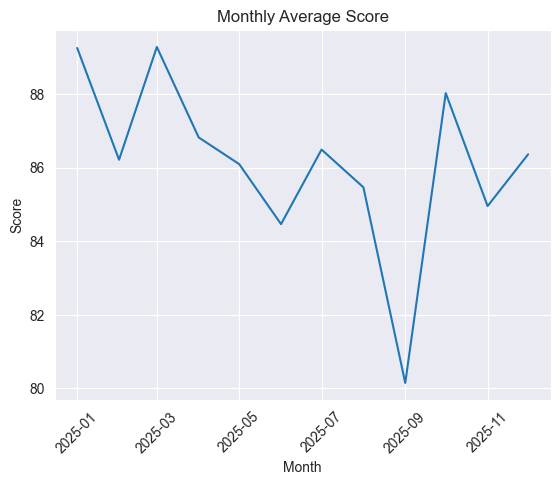

In [38]:
monthly_avg = tutoring.groupby(tutoring['exam_date'].dt.to_period('M'))['score'].mean()
monthly_avg = monthly_avg.reset_index()
monthly_avg.columns = ['months', 'score']
monthly_avg['months'] = monthly_avg['months'].dt.to_timestamp()

fig, ax = plt.subplots()

sns.lineplot(data=monthly_avg, x='months', y='score', ax=ax)
ax.set_xlabel('Month')
ax.set_ylabel('Score')
ax.set_title('Monthly Average Score')
plt.xticks(rotation=45)
plt.show()


Text(0.5, 1.0, 'Number of Students Types')

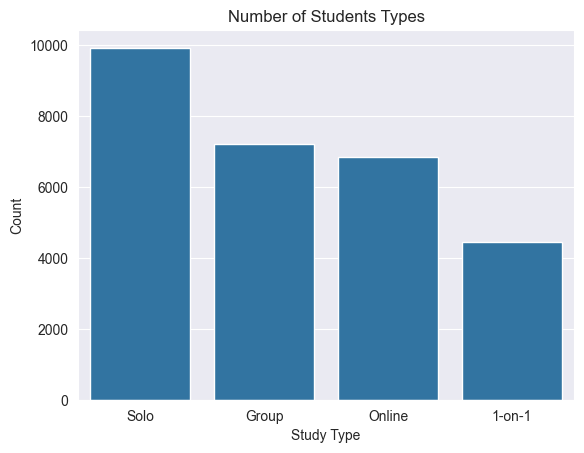

In [41]:
fig, ax = plt.subplots()
order = tutoring['study_type'].value_counts().index
sns.countplot(data=tutoring, x='study_type', order=order, ax=ax)
ax.set_xlabel('Study Type')
ax.set_ylabel('Count')
ax.set_title('Number of Students Types')

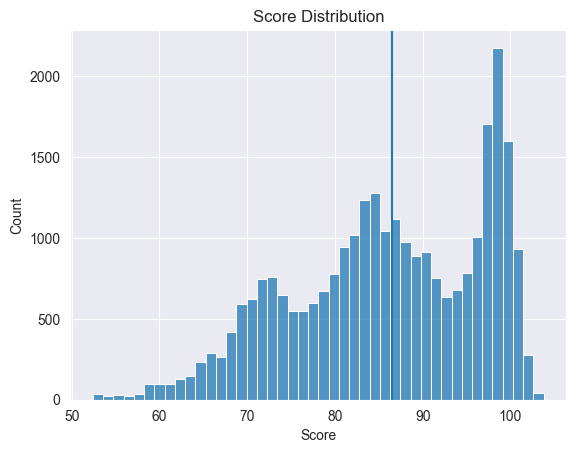

In [45]:
fig, ax = plt.subplots()

sns.histplot(tutoring, x='score', ax=ax)
ax.axvline(tutoring['score'].median())
ax.set_xlabel('Score')
ax.set_ylabel('Count')
ax.set_title('Score Distribution')
plt.show()

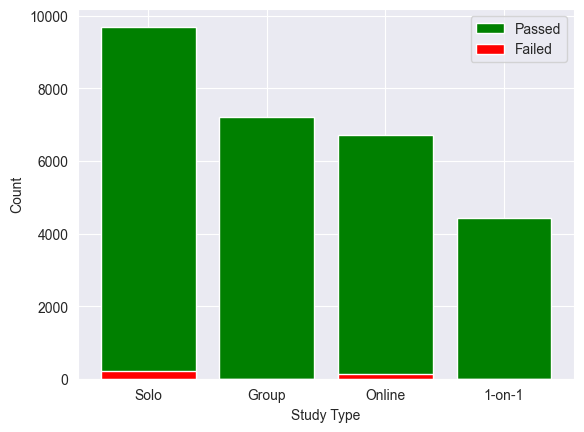

In [62]:
fig , ax = plt.subplots()
passed_counts = tutoring[tutoring['passed'] == 'Pass']['study_type'].value_counts()
fail_counts = tutoring[tutoring['passed'] == 'Fail']['study_type'].value_counts()

ax.bar(passed_counts.index, passed_counts.values, color='green', label='Passed')
ax.bar(fail_counts.index, fail_counts.values, color='red', label='Failed')
ax.set_xlabel('Study Type')
ax.set_ylabel('Count')
ax.legend()
plt.show()

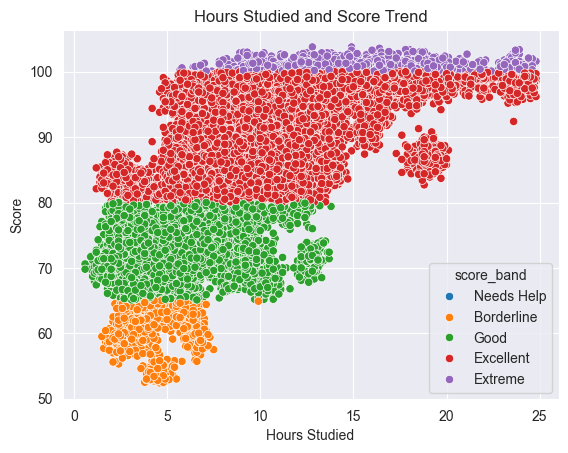

In [64]:
fig, ax = plt.subplots()

sns.scatterplot(data=tutoring,x='hours_studied', y='score', ax=ax, hue='score_band')
ax.set_xlabel('Hours Studied')
ax.set_ylabel('Score')
ax.set_title('Hours Studied and Score Trend')
plt.show()

## Part 18. Multiple Matplotlib subplots

Create a 2×2 grid with:
1. histogram of hours studied,
2. boxplot of score by study type,
3. bar plot of average score by region,
4. monthly average score line plot.

This part helps you practice:
- `plt.subplots(2, 2)`
- indexing axes like `ax[0, 1]`
- `tight_layout()`

In [ ]:
# TODO:
# Build a 2x2 subplot dashboard with the four plots listed above.

## Part 19. Seaborn practice

Create these plots:
1. scatterplot of `hours_studied` vs `score`, colored by `study_type`
2. regplot of `hours_studied` vs `score`
3. boxplot of score by study type
4. histogram of score, split by pass/fail
5. correlation heatmap for the numeric columns
6. a faceted categorical plot by region

Suggested numeric columns for the heatmap:
- `hours_studied`
- `attendance_pct`
- `practice_tests`
- `sleep_hours`
- `score`
- `tutor_rating`

In [ ]:
# TODO:
# Create the six seaborn plots listed above.
# Tip:
# - use fig, ax = plt.subplots() for most seaborn plots
# - use sns.catplot(...) for the faceted plot

## Part 20. Export your work

Save:
- the cleaned full dataset,
- the grouped summary,
- the top students table.

Use:
- `to_csv(..., index=False)`

In [ ]:
# TODO:
# Export:
# - df
# - summary
# - top_students
# to CSV files with sensible names.

## Final reflection questions

Write short answers in Markdown:
1. Which variables seem most related to higher scores?
2. Which study type appears strongest on average?
3. Do outliers change your interpretation?
4. Which plot was most useful and why?
5. What is one thing you would clean differently in a real project?